In [ ]:
import numpy as np
#dataset
x=np.array([1,2,3,4])
y=np.array([3,5,7,9])
#initial values
m=0
b=0
learning_rate=0.01
epochs=1000
n=len(x)
for i in range(epochs):
    #predictions
    y_pred=m*x+b
    #gradiants
    dm=(-2/n)*np.sum(x*(y-y_pred))
    db=(-2/n)*np.sum(y-y_pred)
    #update parameters
    m=m-learning_rate*dm
    b=b-learning_rate*db
print("Slope(m):",m)
print("Intercept(b):",b)


Slope(m): 2.0048610156782556
Intercept(b): 0.9857080211211781


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
#Sample Data
df = pd.DataFrame({'Experiance' : [1, 2, 3, 4, 5], 'Salary': [30000, 35000, 40000, 45000, 50000]
})
# Input Feature
x = df[['Experiance']]
# Target Variable (y)
y = df['Salary']

In [ ]:
# Create Model
model = LinearRegression()
# Train Model (OLS happens here)
model.fit(x,y)
# Predict Salary
predictions = model.predict(x)
# Results
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Predictions:", predictions)

Slope: 5000.0
Intercept: 25000.0
Predictions: [30000. 35000. 40000. 45000. 50000.]


In [ ]:
new_experience = pd.DataFrame({'Experiance': [6, 7, 8, 9]})
# Predict salary for new values
new_predictions = model.predict(new_experience)

print("Predicted Salaries for 6, 7, 8, 9" )
print(new_predictions)

Predicted Salaries for 6, 7, 8, 9
[55000. 60000. 65000. 70000.]


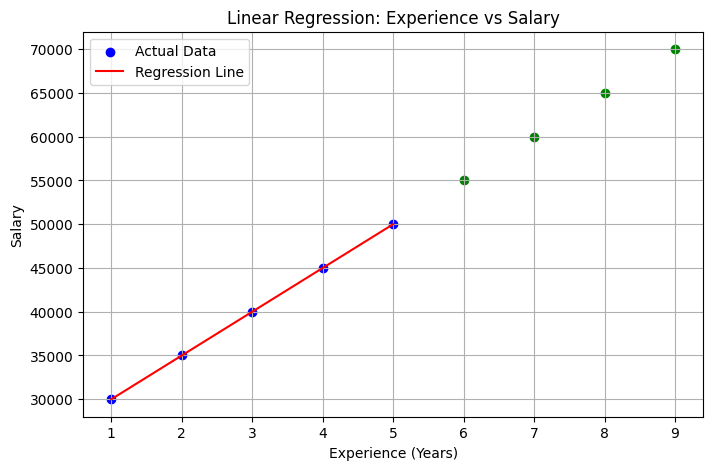

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Original data points
plt.scatter(df['Experiance'], df['Salary'], color='blue', label='Actual Data')

# Regression line (trained data)
plt.plot(df['Experiance'], predictions, color='red', label='Regression Line')

# New predictions
plt.scatter(new_experience['Experiance'], new_predictions, color='green')

# Labels
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")

plt.legend()
plt.grid()
plt.show()

### Multiple Regression

In [ ]:
# Multiple Regression Code

import pandas as pd
from sklearn.linear_model import LinearRegression

# Dataset
df = pd.DataFrame({
    'Area':[1000,1200,1500,1800,2000],
    'Bedrooms':[2,3,3,4,4],
    'Age':[10,8,5,4,2],
    'Price':[300000,350000,450000,500000,600000]
})

# Features
X = df[['Area','Bedrooms','Age']]   #Using multiple features.

# Target
y = df['Price']

# Model
model = LinearRegression()

# Train
model.fit(X,y)   #Learns the relationship between all features and price.

# Prediction
pred = model.predict(X)   #predict house price
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Predictions:", pred)

Coefficients: [  -145.87650228  54786.57273104 -15758.3920431 ]
Intercept: 603750.5180273441
Predictions: [247109.40737671 305408.20555325 347948.6116867  399906.75507667
 499627.02030667]


### New DataFrame

In [ ]:
new = pd.DataFrame({
    'Area':[1200,1500,1800,2200,2000],
    'Bedrooms':[1,2,3,3,4],
    'Age':[15,12,10,3,2]
})

new_pred = model.predict(new)
print(new_pred)
print("Predictions:",pred)

[247109.40737671 305408.20555325 347948.6116867  399906.75507667
 499627.02030667]
Predictions: [247109.40737671 305408.20555325 347948.6116867  399906.75507667
 499627.02030667]


In [ ]:
#VIF Code
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Features
X = df[['Area','Bedrooms','Age']]
# VIF Calculation
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
print(vif)

    Feature        VIF
0      Area  49.009649
1  Bedrooms  36.439444
2       Age   3.861139


## 3. Polynominal Regression

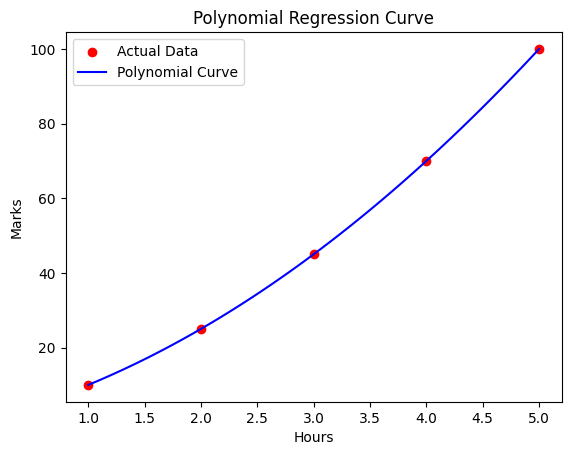

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# Sample dataset
df = pd.DataFrame({
    'Hours': [1, 2, 3, 4, 5],
    'Marks': [10, 25, 45, 70, 100]
})
X = df[['Hours']]
y = df['Marks']
# Polynomial transformation
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
# Model training
model = LinearRegression()
model.fit(X_poly, y)
# Smooth curve generation (IMPORTANT STEP)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range = pd.DataFrame(X_range, columns=['Hours'])
X_range_poly = poly.transform(X_range)
# Predictions for curve
y_curve = model.predict(X_range_poly)
# Plotting
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_range, y_curve, color='blue', label='Polynomial Curve')
plt.title('Polynomial Regression Curve')
plt.xlabel('Hours')
plt.ylabel('Marks')
plt.legend()
plt.show()

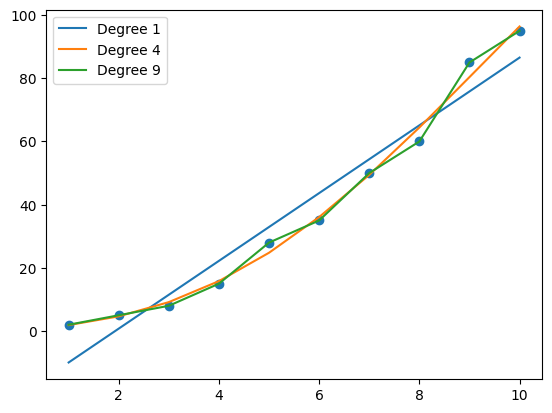

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,5,8,15,28,35,50,60,85,95])
# Degree 1
poly1 = PolynomialFeatures(degree=1)
X1 = poly1.fit_transform(X)
# Degree 4
poly4 = PolynomialFeatures(degree=4)
X4 = poly4.fit_transform(X)
# Degree 9
poly9 = PolynomialFeatures(degree=9)
X9 = poly9.fit_transform(X)
model1 = LinearRegression().fit(X1,y)
model2 = LinearRegression().fit(X4,y)
model9 = LinearRegression().fit(X9,y)
plt.scatter(X,y)
plt.plot(X, model1.predict(X1), label="Degree 1")
plt.plot(X, model2.predict(X4), label="Degree 4")
plt.plot(X, model9.predict(X9), label="Degree 9")
plt.legend()
plt.show()

In [ ]:
##Ridge Code
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100,n_features=5,noise=20,random_state=42)
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
print("Coefficients:")
print(ridge.coef_)

Coefficients:
[62.4844981  98.07649112 57.01070157 52.31272567 35.35343002]


In [ ]:
##Lasso Code
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)
lasso = Lasso(alpha=2.0)
lasso.fit(X, y)
print("Coefficients:")
print(lasso.coef_)

Coefficients:
[17.88753444 54.76076704  0.         60.9632585  90.0800089  68.30461063
 81.35787563  4.03519677  2.86610797 67.99906953]


In [ ]:
##ElasticNet Code
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)
elastic = ElasticNet(
    alpha=3.0,
    l1_ratio=0.5
)
elastic.fit(X, y)
print("Coefficients:")
print(elastic.coef_)

Coefficients:
[10.65990986 22.10890939  0.49979146 25.9235125  33.08321402 34.26097045
 35.7929364  -7.32756763  4.65692898 25.41452644]
